In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


#1)	Preprocess the data (the quality control has already been performed and the data has been cleaned), perform dimensionality reduction and clustering.


In [3]:
# Define the folder containing the input files
data_dir = Path("/Users/rojanmohammadi/Desktop/SingleCell/Assignment_2")

# Map each sample name to its corresponding file
input_files = {
    "SIGAB1": data_dir / "GSM2877127_SIGAB1.h5ad",
    "SIGAC1": data_dir / "GSM2877128_SIGAC1.h5ad",
    "SIGAD1": data_dir / "GSM2877129_SIGAD1.h5ad",
    "SIGAF1": data_dir / "GSM2877130_SIGAF1.h5ad",
    "SIGAG1": data_dir / "GSM2877131_SIGAG1.h5ad",
    "SIGAH1": data_dir / "GSM2877132_SIGAH1.h5ad",
    "SIGAG8": data_dir / "GSM2877133_SIGAG8.h5ad",
    "SIGAH8": data_dir / "GSM2877134_SIGAH8.h5ad"
}

# Store individual AnnData objects
sample_objects = []

for sample_id, file_path in input_files.items():
    # Load data
    sample_data = sc.read_h5ad(file_path)
    
    # Ensure gene names are unique (avoids downstream issues)
    sample_data.var_names_make_unique()
    
    # Add sample metadata
    sample_data.obs["sample"] = sample_id
    
    # Make cell barcodes unique across samples
    sample_data.obs_names = [f"{sample_id}_{cell}" for cell in sample_data.obs_names]
    
    sample_objects.append(sample_data)

# Merge all samples into one AnnData object
adata = ad.concat(
    sample_objects,
    join="outer",
    merge="same"
)

# Save raw counts for later steps (e.g., DE analysis)
adata.layers["raw_counts"] = adata.X.copy()

In [4]:
# Quick checks
print(adata)
print("\nCell numbers per sample:")
print(adata.obs["sample"].value_counts())

AnnData object with n_obs × n_vars = 61122 × 27019
    obs: 'n_genes_by_counts', 'total_counts', 'sample'
    layers: 'raw_counts'

Cell numbers per sample:
sample
SIGAB1    8427
SIGAG1    7947
SIGAG8    7854
SIGAF1    7591
SIGAH1    7563
SIGAD1    7486
SIGAC1    7433
SIGAH8    6821
Name: count, dtype: int64


In [5]:
# check to confirm raw counts
print("\nRaw count range:")
print("Min:", np.min(adata.X))
print("Max:", np.max(adata.X))


Raw count range:
Min: 0.0
Max: 3828.0


The data showed a wide range, confirming that the dataset contained raw counts prior to normalization and transformation.

In [6]:
# Normalise total counts per cell to 10,000
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)
adata.layers["normalised"] = adata.X.copy()

# Log-transform the normalised data
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

# Store the log-normalised data snapshot for later use
adata.raw = adata.copy()

In [7]:
# Check value range after normalisation and log transformation
print("Data range after log-normalisation:")
print("Min:", np.min(adata.X))
print("Max:", np.max(adata.X))

Data range after log-normalisation:
Min: 0.0
Max: 8.620989


In [8]:
# Identify highly variable genes across samples using raw counts
sc.pp.highly_variable_genes(
    adata,
    layer="raw_counts",
    n_top_genes=2000,
    flavor="seurat_v3",
    batch_key="sample"
)

Highly variable genes were identified using raw count data (Seurat v3 method) while downstream analyses such as PCA and clustering are going to  perform on log-normalised data to ensure stable variance and improved structure detection.

In [11]:
# check if we did n_top_genes=2000 correctly:
print("\nNumber of highly variable genes:")
print(adata.var["highly_variable"].sum())


Number of highly variable genes:
2000


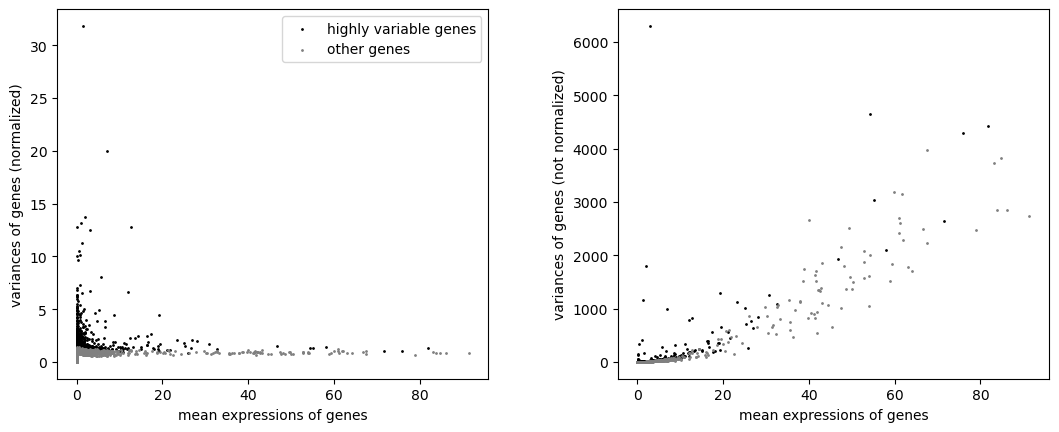

In [12]:
# Visualise highly variable genes
sc.pl.highly_variable_genes(adata)

Highly variable genes were visualised to confirm appropriate selection of genes.

In [13]:
# Keep only highly variable genes
adata = adata[:, adata.var["highly_variable"]].copy()

In [14]:
# Check the new dataset shape
print("\nShape after HVG subsetting:")
print(adata.shape)


Shape after HVG subsetting:
(61122, 2000)


In [15]:
# Scale the data to unit variance and zero mean
sc.pp.scale(adata, max_value=10)

/opt/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [16]:
# Run PCA
sc.tl.pca(adata, svd_solver='arpack')

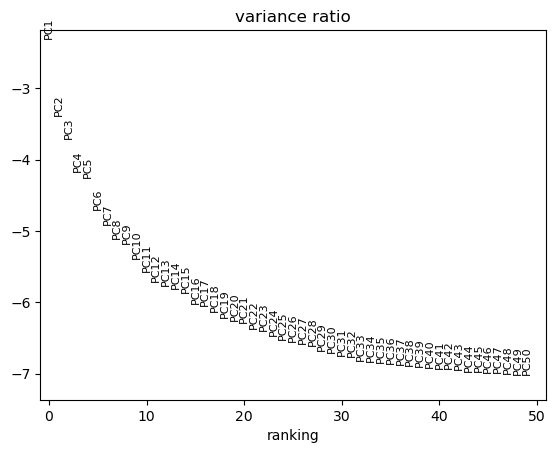

In [17]:
# Plot the explained variance ratio
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

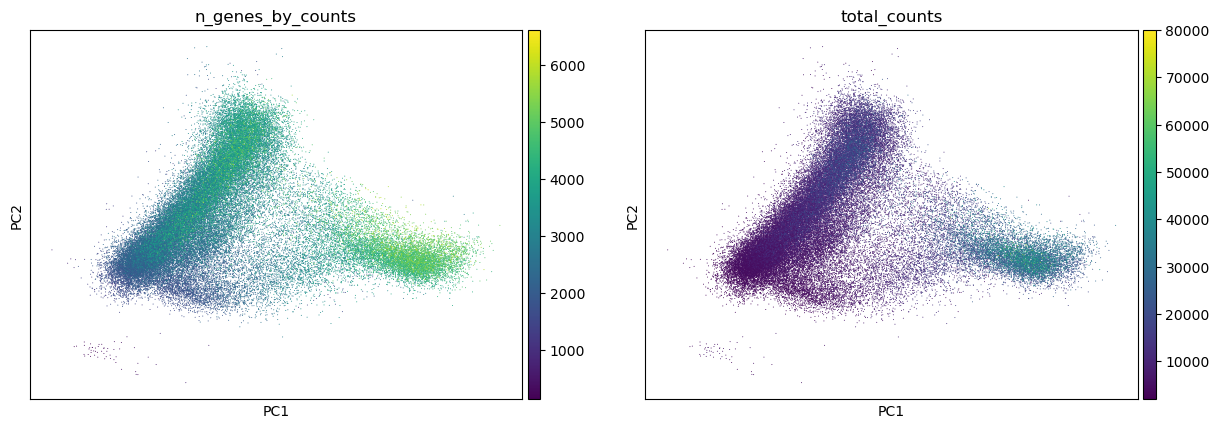

In [18]:
# Optional: visualise PCA coloured by QC metrics
sc.pl.pca(adata, color=['n_genes_by_counts', 'total_counts'])

PCA was used to reduce the dimension of the dataset. The varianceby each principal component  show  that the first components capture most of the biological variation, while later components likely represent noise.

PCA visualisation showed a structured distribution of cells with gradual changes in gene counts and total counts, meaning that biological variation are strong and it is not technical noise.

In [19]:
# Select number of PCs based on PCA variance plot

# Construct neighbourhood graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)

number of principal components was selected based on the PCA variance ratio plot. As the decline became more gradual after the initial components, 20 PCs were good choice to capture sufficient biological variation .
Including more PCs (30) may add noise and reduce clustering performance

In [21]:
# Compute a two-dimensional UMAP embedding
sc.tl.umap(adata)

In [22]:
# Run Leiden clustering
sc.tl.leiden(adata, resolution=0.5, key_added="clusters")

/var/folders/q4/s5t68271385g7rjhxfmf1cj00000gn/T/ipykernel_36740/174725028.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added="clusters")


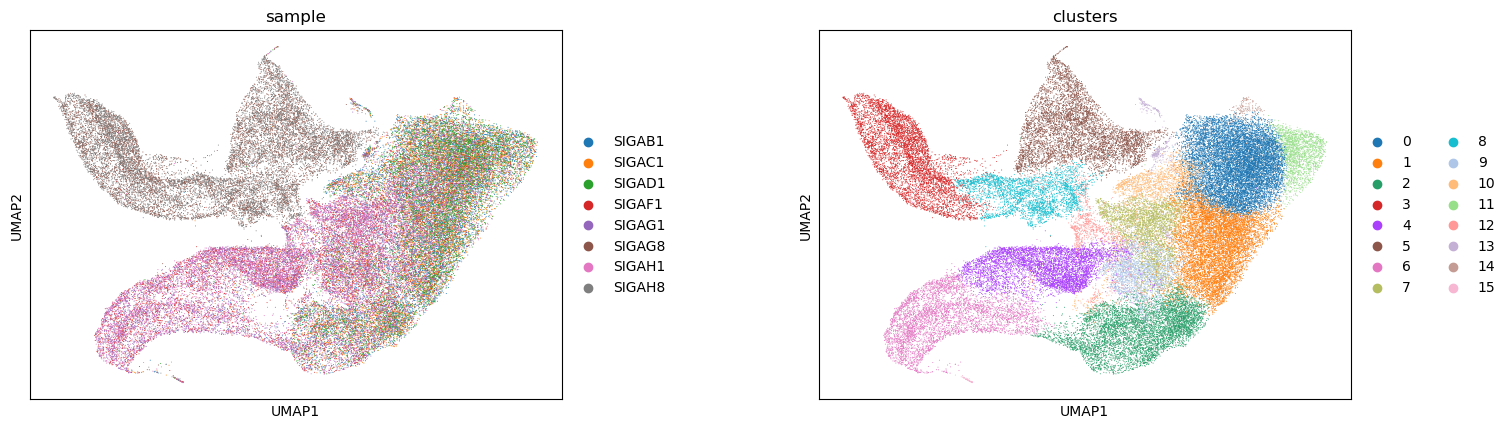

In [25]:
# UMAP coloured by clusters and sample
sc.pl.umap(
    adata,
    color=["sample", "clusters"],
    wspace=0.35
)

The UMAP coloured by sample:
shows that cells from different samples are well mixed, which means there is no strong batch effects, meaning the observed variation is more biological rather than technical.

The UMAP coloured by clusters:
shows  separated groups of cells, indicating that the clustering  identified distinct cell populations successfully.

The overall structure appears a countinuous branching, that is  consistent with the process of haematopoietic differentiation.

Clusters are clearly separated, indicating distinct cell types, while smooth connections between them suggest gradual cell differentiation.

#2)	Perform a differential expression analysis using the previously gained clustering results, what are the top 5 differentially expressed genes per cluster? 

In [29]:
sc.tl.rank_genes_groups(
    adata,
    groupby="clusters",   
    method="wilcoxon",
    use_raw=True,
    pts=True
)

use_raw=True ensures that differential expression is performed on the full gene expression matrix, not just the highly variable genes, since important marker genes may not be included in the HVG subset.

In [30]:
markers_df = sc.get.rank_genes_groups_df(adata, group=None)

In [31]:
top5_per_cluster = (
    markers_df
    .groupby("group", observed=False)
    .head(5)
    .loc[:, ["group", "names", "logfoldchanges", "pvals_adj"]]
    .copy()
)

top5_per_cluster

,group,names,logfoldchanges,pvals_adj
0,0,mt-Co1,0.682940,0.000000e+00
1,0,Sox4,2.023143,0.000000e+00
2,0,Cd34,2.204829,0.000000e+00
3,0,Pim1,2.273856,0.000000e+00
4,0,Rps27,0.454944,0.000000e+00
...,...,...,...,...
405285,15,Hba-a2,14.391863,8.808142e-34
405286,15,Hbb-bs,14.526554,8.808142e-34
405287,15,Hba-a1,13.727269,8.808142e-34
405288,15,Hbb-bt,12.435732,8.808142e-34


In [35]:
adata.obs["clusters"].nunique()


16

In [33]:
top5_per_cluster.groupby("group").size()

group
0     5
1     5
10    5
11    5
12    5
13    5
14    5
15    5
2     5
3     5
4     5
5     5
6     5
7     5
8     5
9     5
dtype: int64

To verify the results, the output was grouped by cluster to ensure that exactly five genes were selected for each cluster. This confirmed that the filtering step worked correctly and that the top five differentially expressed genes were obtained per cluster.

In [36]:
# Run differential expression analysis for the selected clustering
sc.tl.rank_genes_groups(
    adata,
    groupby="clusters",
    method="wilcoxon",
    use_raw=True,
    pts=True
)

# Convert results to a dataframe
markers_df = sc.get.rank_genes_groups_df(adata, group=None)

# Remove mitochondrial and ribosomal genes for clearer biological interpretation
markers_df_filtered = markers_df[
    ~markers_df["names"].str.startswith(("mt-", "Rps", "Rpl"))
].copy()

# Select the top 5 differentially expressed genes per cluster
top5_per_cluster = (
    markers_df_filtered
    .groupby("group", observed=False)
    .head(5)
    .loc[:, ["group", "names", "logfoldchanges", "pvals_adj"]]
    .copy()
)

# Assign a rank within each cluster
top5_per_cluster["rank"] = (
    top5_per_cluster
    .groupby("group", observed=False)
    .cumcount()
)

# Reshape into a clean summary table
top5_table = top5_per_cluster.pivot(
    index="group",
    columns="rank",
    values="names"
)

# Rename columns for clarity
top5_table.columns = [f"Top_{i+1}" for i in top5_table.columns]
top5_table = top5_table.sort_index()

# Display final table
print(top5_table)

        Top_1     Top_2    Top_3   Top_4   Top_5
group                                           
0        Sox4      Cd34     Pim1  Adgrl4  Malat1
1        Mcm3       Ung     Mcm6   Cdca7   Hells
10      Ccnb2     Hmgb1      B2m   H2bc4   Cenpa
11     Malat1       Hlf   Ifitm1   Txnip  Ifitm3
12       Lmo4      Cpa3    Ms4a2   Csrp3    Cd63
13     Tmsb4x     Crip1   Coro1a    Cd52    Lsp1
14      Isg15    Ifitm3    Oasl2    Rtp4   Ifit1
15     Hba-a2    Hbb-bs   Hba-a1  Hbb-bt   Alas2
2       Top2a     Mki67     H1f5   Hmgb2  Tuba1b
3       Hspe1  Hsp90aa1  Atp5mc1     Mt2   Blvrb
4        Apoe   S100a10    Vamp5  Ifngr1    Aqp1
5      Eef1a1      Tpt1   Eef1b2   Rack1   Prtn3
6       Ermap      Car2    Blvrb  Minpp1    Aqp1
7         Mpo      Ctsg    Prtn3   Ap3s1   Elane
8        Tpt1    Eef1a1    Rack1  Eef1b2   Vamp5
9        Pbx1    Itga2b    Pdcd4   Rap1b     Cd9


Differential expression analysis was performed using the Wilcoxon rank-sum test. Mitochondrial and ribosomal genes were removed to improve biological interpretability. The top five differentially expressed genes per cluster were then selected and summarised in a table.

#3)	Produce a UMAP with cells coloured by their clusters and another coloured by the cell type.

In [38]:
marker_dict = {
    'HSCs': ['Procr'],
    'Erythroids': ['Gata1', 'Klf1', 'Epor', 'Hba-a2', 'Hba-a1', 'Spi1'],
    'Neutrophils': ['Elane', 'Cebpe', 'Ctsg', 'Mpo', 'Gfi1'],
    'Monocytes': ['Irf8', 'Csf1r', 'Ctsg', 'Mpo'],
    'Megakaryocytes': ['Itga2b', 'Pbx1', 'Sdpr', 'Vwf'],
    'Basophils': ['Mcpt8', 'Prss34'],
    'B cells': ['Cd19', 'Vpreb2', 'Cd79a'],
    'Mast cells': ['Cma1', 'Gzmb', 'Kit'],
    'Mast cells & Basophils': ['Ms4a2', 'Fcer1a', 'Cpa3']
}

marker_dict_present = {
    celltype: [g for g in genes if g in adata.raw.var_names]
    for celltype, genes in marker_dict.items()
}

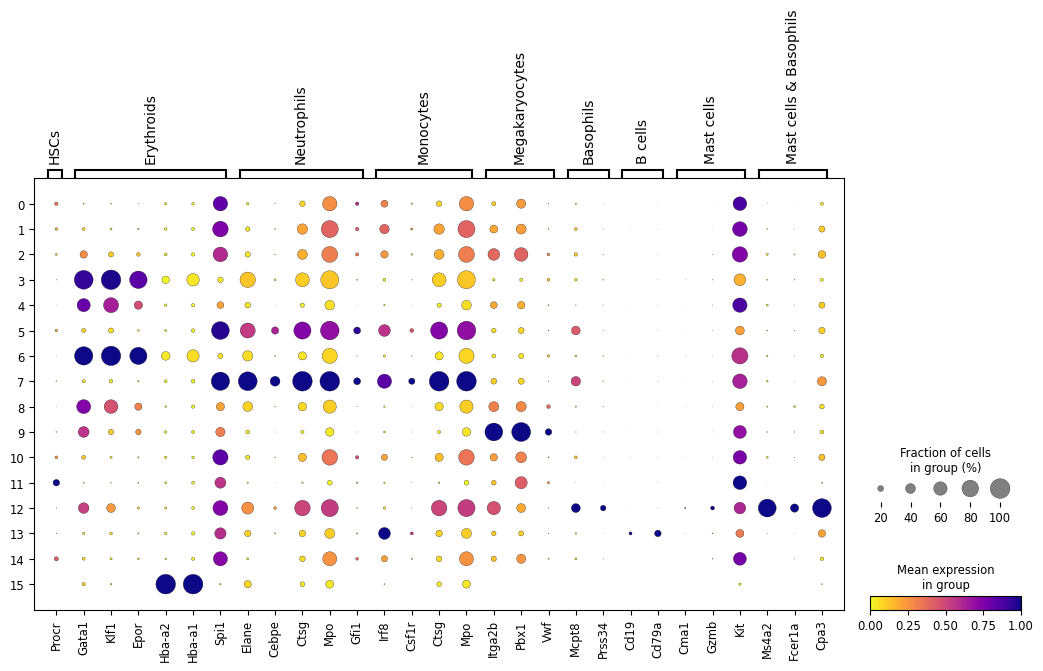

In [39]:
# Dotplot of marker genes across clusters
sc.pl.dotplot(
    adata,
    var_names=marker_dict_present,
    groupby='clusters',
    color_map='plasma_r',
    standard_scale='var',
    use_raw=True
)

In [50]:
annotation_dict = {
    '0':  'Myeloid progenitors',
    '1':  'Cycling progenitors',
    '2':  'Cycling progenitors',
    '3':  'Erythroid progenitors',
    '4':  'Monocytes',
    '5':  'Myeloid-like cells',
    '6':  'Erythroids',
    '7':  'Neutrophils',
    '8':  'Myeloid-like cells',
    '9':  'Megakaryocytes',
    '10': 'Cycling progenitors',
    '11': 'HSCs',
    '12': 'Mast cells & Basophils',
    '13': 'Lymphoid-like cells',
    '14': 'Interferon-responsive cells',
    '15': 'Erythroids'
}

In [51]:
adata.obs["Cell_type"] = adata.obs["clusters"].map(annotation_dict).astype("category")

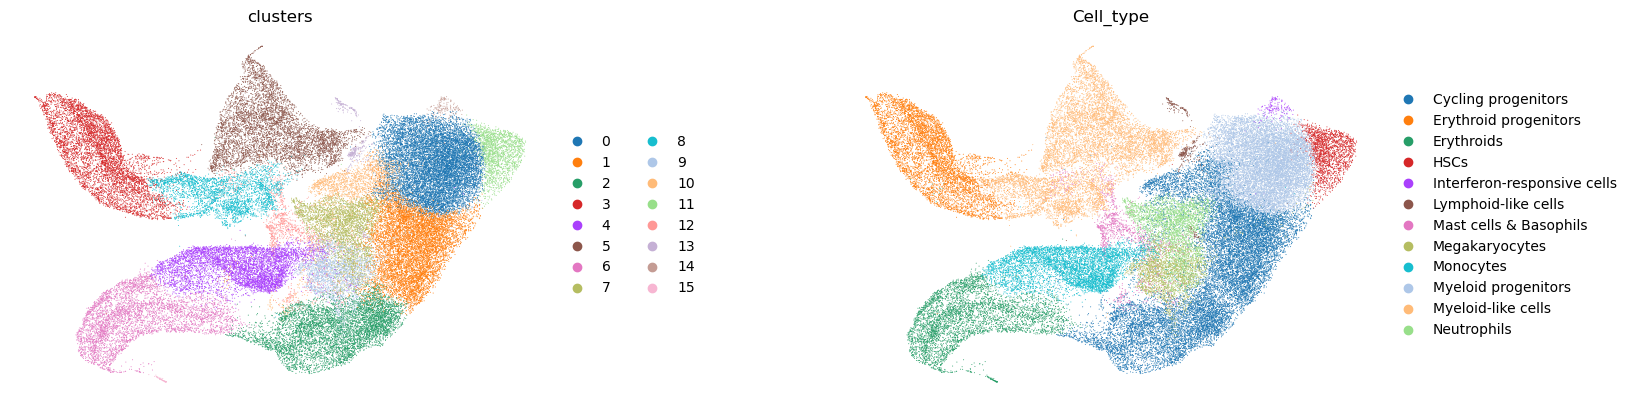

In [52]:
sc.pl.umap(
    adata,
    color=["clusters", "Cell_type"],
    ncols=2,
    wspace=0.4,
    frameon=False
)

Cell types were assigned to clusters based on the expression of the provided marker genes, supported by the differential expression results. 

Although stem cells are not centrally located, they are connected to different lineages through gradual transitions, indicating ongoing differentiation.

The number of clusters is higher than the number of annotated cell types because multiple clusters can represent similar biological populations or different states of the same lineage. Therefore, clusters were grouped into broader cell types based on shared marker gene expression.

#4)	Perform DTP trajectory analysis. Produce a UMAP coloured by the DTP trajectory pseudotime. How many lineages are there? 

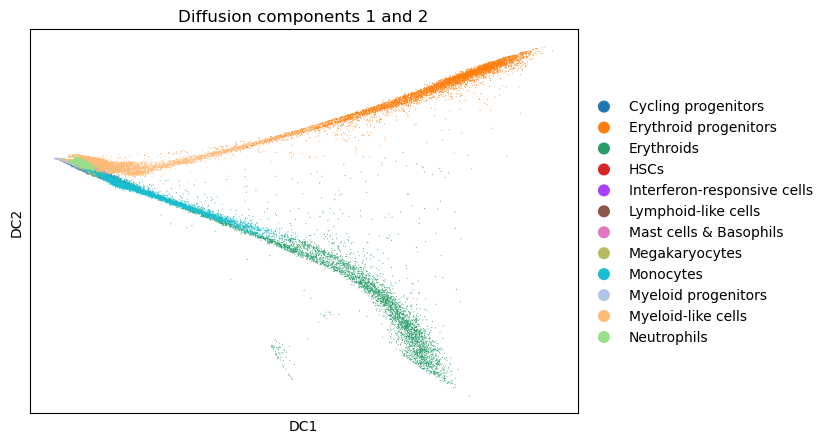

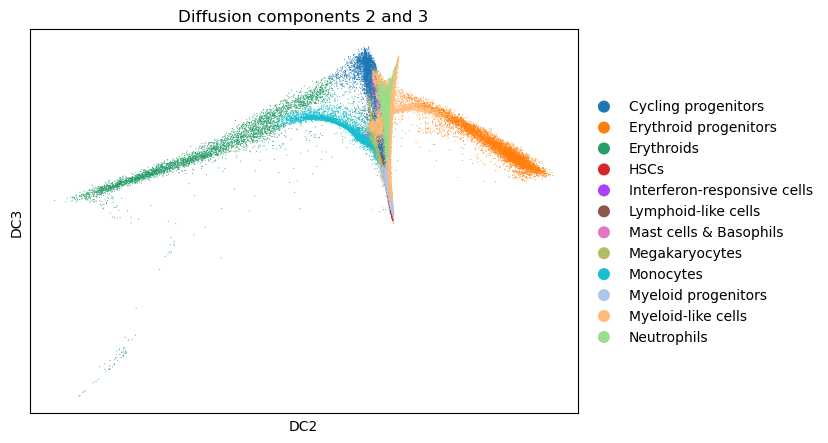

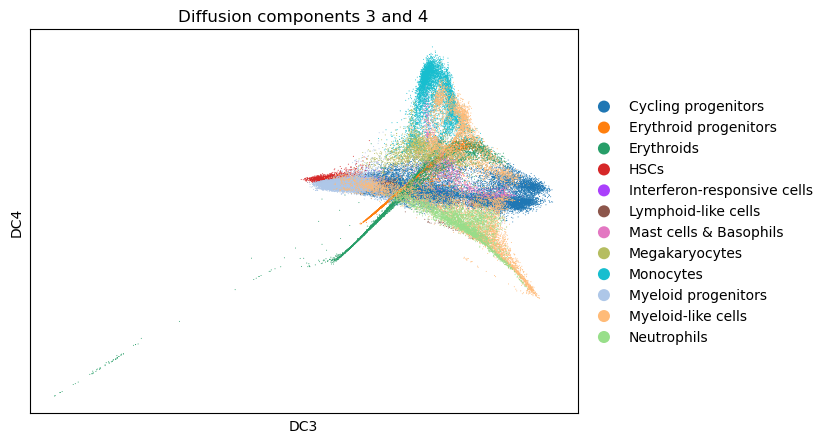

In [53]:
# Compute diffusion map for DPT
sc.tl.diffmap(adata)

# Visualise diffusion components
sc.pl.scatter(
    adata,
    basis="diffmap",
    color="Cell_type",
    components=[1,2],
    frameon=True,
    title="Diffusion components 1 and 2"
)

sc.pl.scatter(
    adata,
    basis="diffmap",
    color="Cell_type",
    components=[2,3],
    frameon=True,
    title="Diffusion components 2 and 3"
)

sc.pl.scatter(
    adata,
    basis="diffmap",
    color="Cell_type",
    components=[3,4],
    frameon=True,
    title="Diffusion components 3 and 4"
)



DC1–DC2
This plot shows the overall structure of the trajectory. A common starting region is visible, from which  main branches emerge. 

DC2–DC3
This plot highlights the branching structure more clearly and is biologically interpretable. The central region is more distinct, and the separation into different trajectories is easier to observe. This provides the clearest view of the differentiation structure

DC3–DC4
This plot shows the main trajectory less clearly.it is less suitable for identifying the main trajectory but useful for observing finer details.

Overall, these three plots indicate that the dataset contains a continuous and branching structure consistent with a differentiation process.

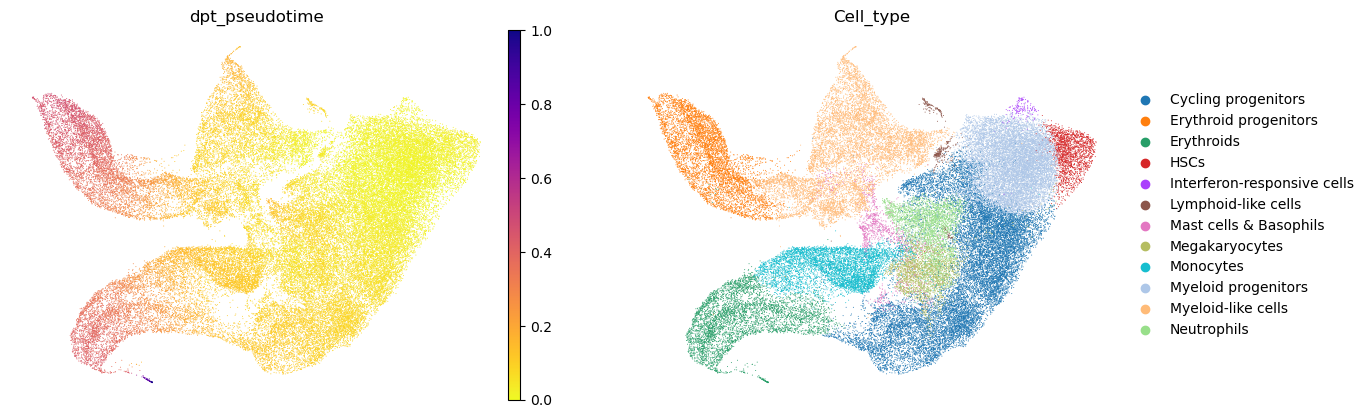

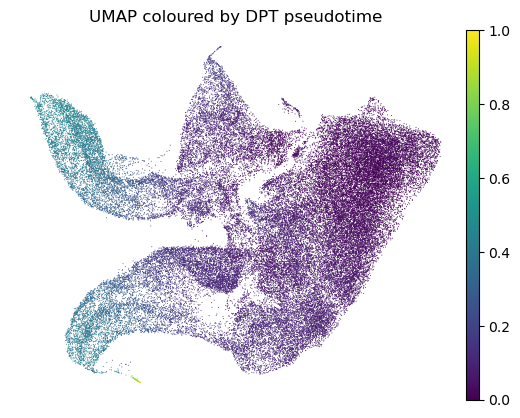

In [55]:
# Select a root cell from the HSC population
candidate_cells = adata.obs_names[adata.obs["Cell_type"] == "HSCs"]
root_cell = candidate_cells[0]
adata.uns["iroot"] = adata.obs_names.get_loc(root_cell)

# Run DPT pseudotime analysis
sc.tl.dpt(adata)

# Visualise pseudotime on UMAP
sc.pl.umap(
    adata,
    color=["dpt_pseudotime", "Cell_type"],
    color_map="plasma_r",
    ncols=2,
    frameon=False
)

# UMAP coloured only by pseudotime
sc.pl.umap(
    adata,
    color="dpt_pseudotime",
    title="UMAP coloured by DPT pseudotime",
    frameon=False
)

Three distinct trajectories are observed in the diffusion map. One branch corresponds to a clearly defined lineage, while two additional branches represent closely related trajectories that may belong to the same broader lineage. This is consistent with the expected structure of haematopoietic differentiation.

#5)	Are there any limitations of this experiment? Would you make any changes to this analysis? Can you think of next steps for this analysis?

This analysis has several limitations. Cell type annotation was performed using a limited number of marker genes, which may have led to some clusters not being clearly defined. In addition, clustering results depend on parameter choices, which can influence the final grouping of cells. Furthermore, pseudotime represents an inferred ordering of cell states rather than true biological time, and therefore may not fully capture the exact progression of differentiation.

The analysis could be improved by incorporating a broader set of marker genes to achieve more accurate cell type identification. It would also be beneficial to assess differences between samples and apply batch correction methods if necessary. Exploring different clustering parameters and alternative analytical approaches could further strengthen the robustness of the results.

As next steps, gene expression changes along pseudotime could be analysed to better understand dynamic processes during differentiation. Cell type annotations could be further validated, and the findings could be confirmed using additional datasets or alternative trajectory inference methods. Additionally, examining the behaviour of different cell populations across the dataset may provide deeper biological insights.